# 1.6 Resource availabilities
**Responsible:** _(Aldo Patrone)_

Fits the availability model in resources/availability.py from the BPIC-17 log and exports it as an artifact the engine loads at runtime.

- **Basic:** fixed interval (Mon-Fri 08:00-18:00) for every resource.
- **Advanced:** per-resource calendars learned from observed timestamps. BPIC-17 has no system-vs-human attribute, so a data-driven per-resource calendar replaces a fixed system-always-on rule.

Mode is artifact-driven: if results/availability_calendars.json exists the engine uses the advanced model, otherwise the basic interval.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from resources.log_loader import load_slim_log
from resources import availability

df = load_slim_log('../data/BPI Challenge 2017.xes', '../data/bpic17_slim.parquet')
ts = pd.to_datetime(df['time:timestamp'], utc=True)
df = df.assign(weekday=ts.dt.weekday, hour=ts.dt.hour)
print(len(df), 'events,', df['org:resource'].nunique(), 'resources')

1202267 events, 149 resources


## Temporal activity pattern
The weekday-by-hour heatmap motivates the model: activity concentrates on weekday daytime, and a fixed Mon-Fri 08-18 window only approximates it.

saved ../results/availability_heatmap.png


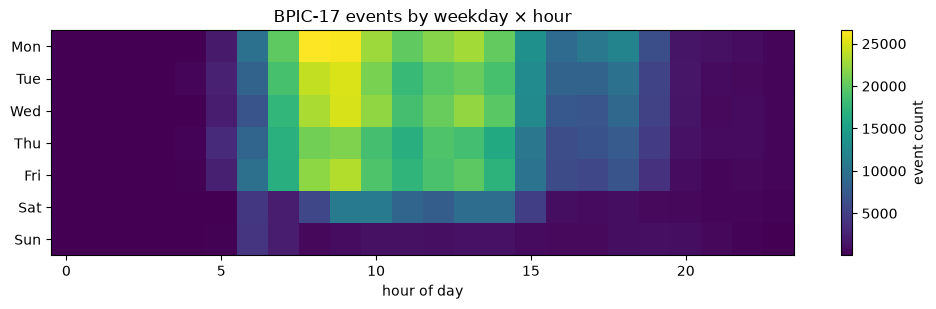

In [2]:
heat = df.groupby(['weekday', 'hour']).size().unstack(fill_value=0).reindex(index=range(7), columns=range(24), fill_value=0)
fig, ax = plt.subplots(figsize=(10, 3.2))
im = ax.imshow(heat.values, aspect='auto', cmap='viridis')
ax.set_yticks(range(7)); ax.set_yticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
ax.set_xlabel('hour of day'); ax.set_title('BPIC-17 events by weekday × hour')
fig.colorbar(im, ax=ax, label='event count')
fig.tight_layout(); fig.savefig('../results/availability_heatmap.png', dpi=120)
print('saved ../results/availability_heatmap.png')

## Advanced: learned per-resource calendars
For each resource the model keeps the (weekday, hour) buckets whose event count reaches "max(min_events, threshold_frac × peak)", suppressing rare off-hours noise.

learned calendars for 149 resources; mean 44.4 active buckets of 168
saved ../results/availability_calendar_sizes.png


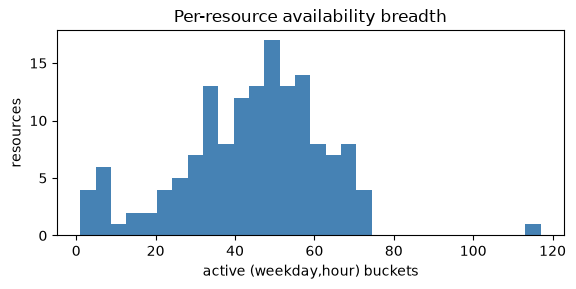

In [3]:
calendars = availability.learn_calendars(df)
availability.save_calendars(calendars, '../results/availability_calendars.json')
cal_t = {r: {(int(w), int(h)) for w, h in b} for r, b in calendars.items()}
sizes = [len(v) for v in cal_t.values()]
print('learned calendars for', len(cal_t), 'resources; mean %.1f active buckets of 168' % np.mean(sizes))

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(sizes, bins=30, color='steelblue')
ax.set_xlabel('active (weekday,hour) buckets'); ax.set_ylabel('resources')
ax.set_title('Per-resource availability breadth')
fig.tight_layout(); fig.savefig('../results/availability_calendar_sizes.png', dpi=120)
print('saved ../results/availability_calendar_sizes.png')

## Basic vs. advanced: event coverage
Share of real events that fall inside each availability model. The learned calendars capture far more of the real activity than the fixed interval, justifying the advanced model.

In [4]:
in_basic = ((df['weekday'] < 5) & (df['hour'] >= 8) & (df['hour'] < 18)).mean()
samp = df.sample(min(100000, len(df)), random_state=1)
in_cal = np.mean([(int(w), int(h)) in cal_t.get(str(r), set())
                  for r, w, h in zip(samp['org:resource'], samp['weekday'], samp['hour'])])
print('event coverage  | basic interval: %.1f%%  | learned calendars: %.1f%%' % (100*in_basic, 100*in_cal))

event coverage  | basic interval: 72.0%  | learned calendars: 96.4%


**Result:** The basic Mon-Fri 08-18 interval covers about 72% of real events, the learned per-resource calendars about 96%. The advanced model reflects real availability more faithfully while still constraining each resource to its own pattern.

## Extended evaluation: holdout, efficiency, capacity, enforcement
The full-log coverage (72% vs 96%) is in-sample. A temporal holdout (learn on the first 70% of the log period, test on the last 30%) checks generalization. The learned model's decisive benefit is efficiency: fewer assumed available hours per week at equal out-of-sample faithfulness. The capacity heatmap and an enforcement spot-check (who_is_available returns only resources whose calendar holds the weekday-hour bucket) confirm the model constrains availability to real working windows.

holdout coverage (train 70% / test 30%) | basic: 72.3% | learned: 73.1%
mean available hours/week: 44.4 (learned) vs 50.0 (fixed Mon-Fri 08-18)
saved ../results/availability_capacity_heatmap.png
enforced Mon 10:00 bucket=(0, 10) -> 119 available, all-in-calendar=True
enforced Mon 03:00 bucket=(0, 3) ->   0 available, all-in-calendar=True
enforced Sat 10:00 bucket=(5, 10) ->  56 available, all-in-calendar=True


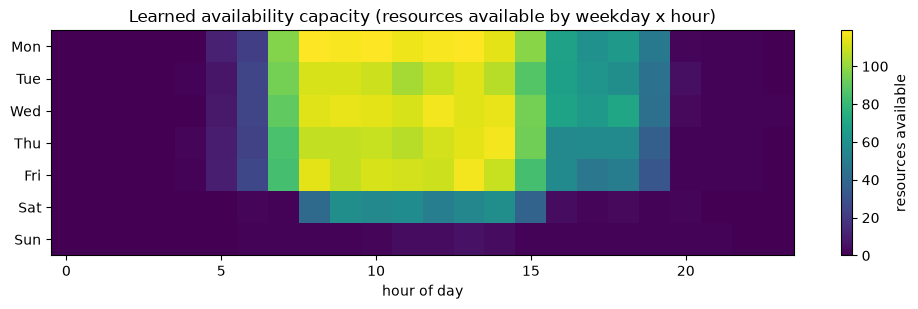

In [5]:
# Extended evaluation (Aldo Patrone): holdout, efficiency, capacity, enforcement
from datetime import datetime
from resources.availability import AvailabilityModel

# (a) temporal holdout: learn calendars on the first 70% of the log period, coverage on the last 30%
order = np.argsort(pd.to_datetime(df['time:timestamp'], utc=True).values, kind='stable')
dfs = df.iloc[order]; cut = int(0.7 * len(dfs)); train, test = dfs.iloc[:cut], dfs.iloc[cut:]
cal_tr = {r: {(int(w), int(h)) for w, h in b} for r, b in availability.learn_calendars(train).items()}
ho_basic = ((test['weekday'] < 5) & (test['hour'] >= 8) & (test['hour'] < 18)).mean()
ho_adv = np.mean([(int(w), int(h)) in cal_tr.get(str(r), set())
                  for r, w, h in zip(test['org:resource'], test['weekday'], test['hour'])])
print('holdout coverage (train 70%% / test 30%%) | basic: %.1f%% | learned: %.1f%%' % (100*ho_basic, 100*ho_adv))

# (b) efficiency: mean available hours/week vs the fixed 50 h interval (each bucket = one hour)
print('mean available hours/week: %.1f (learned) vs 50.0 (fixed Mon-Fri 08-18)' % np.mean(sizes))

# (c) learned availability-capacity heatmap: number of resources available per (weekday, hour)
cap = np.zeros((7, 24))
for cal in cal_t.values():
    for (w, h) in cal:
        cap[w, h] += 1
fig, ax = plt.subplots(figsize=(10, 3.2))
im = ax.imshow(cap, aspect='auto', cmap='viridis')
ax.set_yticks(range(7)); ax.set_yticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
ax.set_xlabel('hour of day')
ax.set_title('Learned availability capacity (resources available by weekday x hour)')
fig.colorbar(im, ax=ax, label='resources available')
fig.tight_layout(); fig.savefig('../results/availability_capacity_heatmap.png', dpi=120)
print('saved ../results/availability_capacity_heatmap.png')

# (d) enforcement spot-check: who_is_available returns only resources whose calendar holds the bucket
am = AvailabilityModel(df, artifact_path='../results/availability_calendars.json')  # advanced mode
for t in [datetime(2000, 1, 3, 10, 0), datetime(2000, 1, 3, 3, 0), datetime(2000, 1, 8, 10, 0)]:
    avail = am.who_is_available(t); bucket = (t.weekday(), t.hour)
    ok = all(bucket in cal_t.get(r, set()) for r in avail)
    print('enforced %s bucket=%s -> %3d available, all-in-calendar=%s'
          % (t.strftime('%a %H:%M'), bucket, len(avail), ok))